In [12]:
import pandas as pd
import sqlite3
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(155)

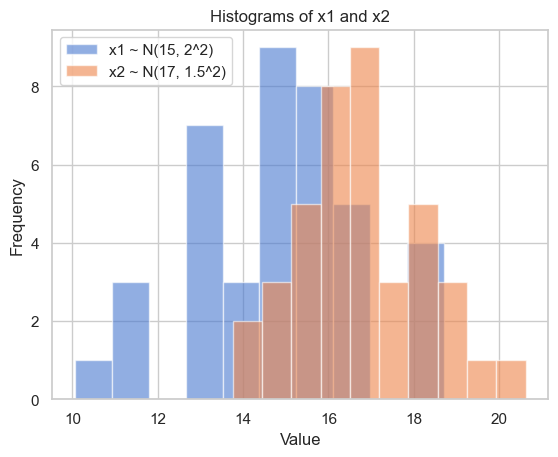

In [13]:
x1 = np.random.normal(loc=15, scale=2, size=40)
x2 = np.random.normal(loc=17, scale=1.5, size=40)

plt.hist(x1, alpha=0.6, label="x1 ~ N(15, 2^2)")
plt.hist(x2, alpha=0.6, label="x2 ~ N(17, 1.5^2)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histograms of x1 and x2")
plt.legend()
plt.show()

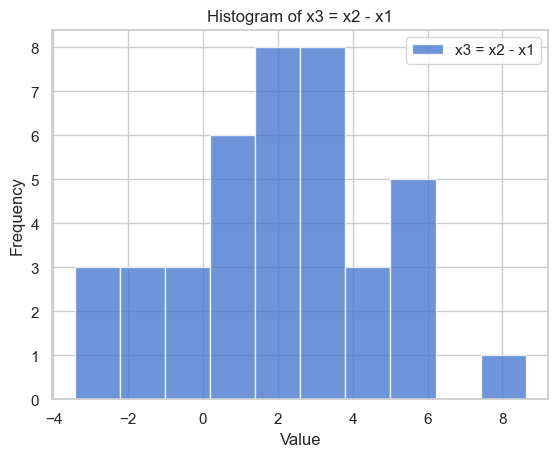

In [14]:
x3 = x2 - x1

plt.hist(x3, alpha=0.8, label="x3 = x2 - x1")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of x3 = x2 - x1")
plt.legend()
plt.show()

In [15]:
import statistics as stats
import scipy.stats as st

# Mean & Median
mean_x1 = np.mean(x1)
median_x1 = np.median(x1)

mean_x3 = np.mean(x3)
median_x3 = np.median(x3)

# Mode (may look strange)
mode_x3 = stats.mode(x3)
print("x1 mean:", mean_x1, "median:", median_x1)
print("x3 mean:", mean_x3, "median:", median_x3, "mode:", mode_x3)

x1 mean: 14.802853912665578 median: 14.895544528517114
x3 mean: 1.9786763220711936 median: 1.992652158933761 mode: -0.39524741677759856


In [16]:
x3_rounded = np.round(x3)
mode_x3_rounded = stats.mode(x3_rounded)
print("Mode of rounded x3:", mode_x3_rounded)

Mode of rounded x3: 2.0


In [17]:
# Sample variance & standard deviation (ddof=1 for sample stats)
var_x1 = np.var(x1, ddof=1)
std_x1 = np.std(x1, ddof=1)
se_x1 = std_x1 / np.sqrt(len(x1))

var_x3 = np.var(x3, ddof=1)
std_x3 = np.std(x3, ddof=1)
se_x3 = std_x3 / np.sqrt(len(x3))

print("x1 variance:", var_x1)
print("x1 std:", std_x1)
print("x1 se:", se_x1)

print("x3 variance:", var_x3)
print("x3 std:", std_x3)
print("x3 se:", se_x3)

x1 variance: 3.800930740085972
x1 std: 1.9495975841403712
x1 se: 0.3082584443322669
x3 variance: 6.95429882623408
x3 std: 2.637100458123293
x3 se: 0.41696219331715434


In [18]:
def summary_stats(arr, name):
    data_range = np.max(arr) - np.min(arr)
    q1 = np.percentile(arr, 25)
    q2 = np.percentile(arr, 50)   # same as median
    q3 = np.percentile(arr, 75)
    iqr = q3 - q1
    
    print(f"{name}:")
    print("  range =", data_range)
    print("  Q1    =", q1)
    print("  Q2    =", q2)
    print("  IQR   =", iqr)
    print()

summary_stats(x1, "x1")
summary_stats(x3, "x3")

x1:
  range = 8.653972842075436
  Q1    = 13.36709336572737
  Q2    = 14.895544528517114
  IQR   = 2.5975437371308274

x3:
  range = 12.051483453898417
  Q1    = 0.5217269812732308
  Q2    = 1.992652158933761
  IQR   = 3.155035904741118



In [20]:
print("More variable:", "x3" if np.var(x3, ddof=1) > np.var(x1, ddof=1) else "x1")

More variable: x3


In [21]:
import pandas as pd

films = pd.read_csv("film.csv", sep="|", quotechar="'")
cats = pd.read_excel("categories.xlsx")

df = films.merge(cats, on="category_id", how="left")
df.head()

,film_id,category_id,title,description,rating,rental_rate,rental_duration,special_features,fulltext,category_name
0,1,6,Academy Dinosaur,A Epic Drama of a Feminist And a Mad Scientist...,PG,0.99,6,"{""Deleted Scenes"",""Behind the Scenes""}",'academi':1 'battl':15 'canadian':20 'dinosaur...,Documentary
1,2,11,Ace Goldfinger,A Astounding Epistle of a Database Administrat...,G,4.99,3,"{Trailers,""Deleted Scenes""}",'ace':1 'administr':9 'ancient':19 'astound':4...,Horror
2,3,6,Adaptation Holes,A Astounding Reflection of a Lumberjack And a ...,NC-17,2.99,7,"{Trailers,""Deleted Scenes""}",'adapt':1 'astound':4 'baloon':19 'car':11 'fa...,Documentary
3,4,11,Affair Prejudice,A Fanciful Documentary of a Frisbee And a Lumb...,G,2.99,5,"{Commentaries,""Behind the Scenes""}",'affair':1 'chase':14 'documentari':5 'fanci':...,Horror
4,5,8,African Egg,A Fast-Paced Documentary of a Pastry Chef And ...,G,2.99,6,"{""Deleted Scenes""}",'african':1 'chef':11 'dentist':14 'documentar...,Family


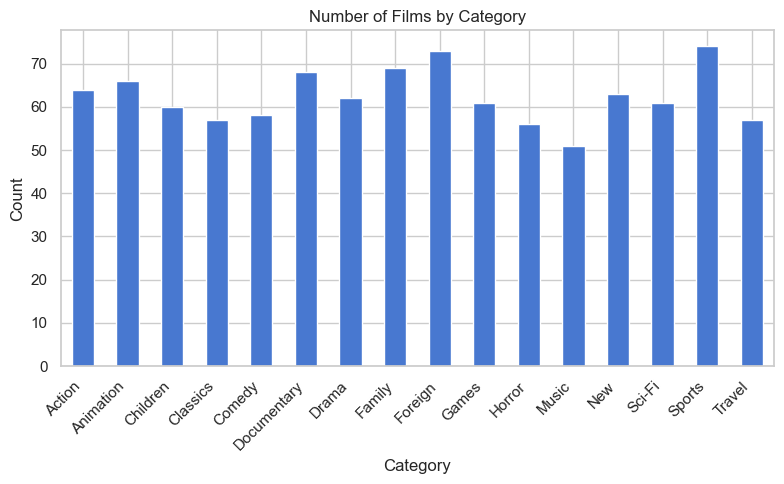

In [22]:
import matplotlib.pyplot as plt

counts = df["category_name"].value_counts().sort_index()

plt.figure(figsize=(8,5))
counts.plot(kind="bar")
plt.title("Number of Films by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/var/folders/dv/jvk0lfm56k5ghp4g27w1sy700000gn/T/ipykernel_97394/153098571.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped, labels=labels, showmeans=True)


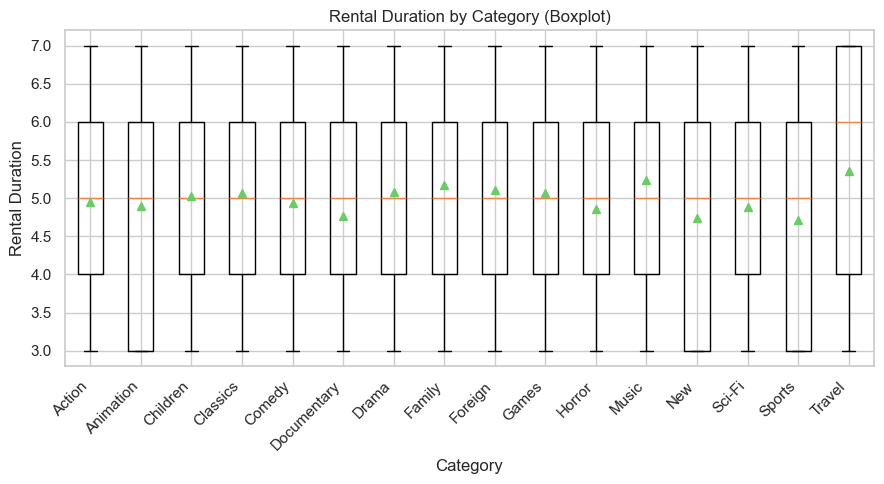

In [23]:
grouped = [g["rental_duration"].values for _, g in df.groupby("category_name")]
labels = [name for name, _ in df.groupby("category_name")]

plt.figure(figsize=(9,5))
plt.boxplot(grouped, labels=labels, showmeans=True)
plt.title("Rental Duration by Category (Boxplot)")
plt.xlabel("Category")
plt.ylabel("Rental Duration")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()